In [1]:
BATCH_SIZES = [8, 16, 32, 64] # numero de elementos procesados conjuntamente en cada iteracion
EPOCHS = 50 # numero de epocas para entrenamiento

In [3]:
##%%capture
#%tensorflow_version 2.x
!pip install tensorflow==2.9.2
import tensorflow as tf
import numpy as np
import os, subprocess, pathlib, time
from google.colab import drive
import matplotlib.pyplot as plt

import tensorflow.keras.layers as layers
import tensorflow.keras.models as models
import tensorflow.keras.optimizers as optimizers


In [4]:
!python --version                     # mostrar version de python
print('Tensorflow ' + tf.__version__) # mostrar version tensorflow


# Montar Google Drive y crear carpetas
drive.mount('/content/gdrive', force_remount=True)

work_dir = '/content/work_dir'                    # directorio de trabajo en local (mas rapido)
dwld_dir = '/content/gdrive/My Drive/dwld_dir'    # directorio de descarga en Google drive personal
subprocess.call(["mkdir","-p",work_dir])          # crear directorio para trabajo
subprocess.call(["mkdir","-p",dwld_dir+'/dataset/'])  # crear directorio para dataset

os.chdir(dwld_dir+'/dataset/')                        # posicionarse en el directorio
# Descargar dataset scenes15 si no esta disponible
if os.path.isfile('./dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/tsv/dataset_scenes15.zip

# Copiar el dataset al directorio local (mayor velocidad de lectura que en Gdrive)
!cp /content/gdrive/My\ Drive/dwld_dir/dataset/dataset_scenes15.zip /content/work_dir/

os.chdir(work_dir)                        # posicionarse en el directorio
if os.path.isdir('./scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

print('El dataset se encuentra descargado en el directorio {} \ny descomprimido en el directorio {} (usado para lectura de datos)'.format(dwld_dir, work_dir))

Python 3.10.12
Tensorflow 2.9.2
Mounted at /content/gdrive
El dataset se encuentra descargado en el directorio /content/gdrive/My Drive/dwld_dir 
y descomprimido en el directorio /content/work_dir (usado para lectura de datos)


In [ ]:
dataset_dir = pathlib.Path(work_dir + '/scenes15/')

# Obtener etiquetas de clase y numero de clases
CLASS_NAMES = np.array([item.name for item in dataset_dir.glob('*')]) #clases son subdirectorios de '/train/'
NUM_CLASSES = len(CLASS_NAMES) # numero total de clases

In [25]:
def generator_dataset(BATCH_SIZE = 16, IMG_HEIGHT = 32, IMG_WIDTH = 32, IMG_CHANNELS = 3, dataset_dir=None):
  # Crear ImageDataGenerator convirtiendo de uint8 a float32 en el rango [0,1].
  img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.20)

  # Obtenemos un iterador sobre los datos de entrenamiento del dataset
  # aplicando el ImageDataGenerator creado anteriormente

  #Añadimos la variable dataset_dir al argumento de la funcion
  #Para poder utilizarla dentro de la funcion

  train_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                            target_size=(IMG_HEIGHT, IMG_WIDTH),
                                            color_mode='rgb',
                                            classes = list(CLASS_NAMES),
                                            class_mode='categorical',
                                            batch_size=BATCH_SIZE,
                                            subset="training",
                                            shuffle=True,
                                            seed=0)

  test_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                            target_size=(IMG_HEIGHT, IMG_WIDTH),
                                            color_mode='rgb',
                                            classes = list(CLASS_NAMES),
                                            class_mode='categorical',
                                            batch_size=BATCH_SIZE,
                                            subset="validation",
                                            shuffle=True,
                                            seed=0)

  return train_data_gen, test_data_gen

In [24]:
def model_creation(IMG_HEIGHT = 32, IMG_WIDTH = 32, IMG_CHANNELS = 3, print_summary = False):
  # definir modelo de red
  model = models.Sequential()

  # incluir capa convolucional C1
  model.add(layers.Conv2D(filters=6,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation='relu',
                          input_shape=(IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)))

  # incluir average pooling S2
  model.add(layers.AveragePooling2D())

  # incluir capa convolucional C3
  model.add(layers.Conv2D(filters=16,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation='relu'))

  # incluir average pooling S4
  model.add(layers.AveragePooling2D())

  # convertir el volumen de datos en vector fila para conectarlo con capa FC
  model.add(layers.Flatten())

  # incluir fully convolutional F5
  model.add(layers.Dense(units=120, activation='relu'))

  # incluir fully convolutional F6
  model.add(layers.Dense(units=84, activation='relu'))

  # incluir salida OUTPUT
  model.add(layers.Dense(units=NUM_CLASSES, activation = 'softmax'))



  # mostar resumen
  if print_summary == True:
    model.summary()


  # definicion con optimizador con valores definidos por el usuario
  LEARNING_RATE = 0.01 # factor de aprendizaje
  model.compile(optimizer=optimizers.SGD(lr=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

  return model

Ejecución

In [29]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
NUM_CLASSES = 15

test_loss_list = []
test_acc_list = []

train_loss_list = []
train_acc_list = []

history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []

# Define dataset_dir here, before the loop
dataset_dir = pathlib.Path(work_dir + '/scenes15/')

# Get CLASS_NAMES before calling generator_dataset
CLASS_NAMES = np.array([item.name for item in dataset_dir.glob('*')]) #clases son subdirectorios de '/train/'


for batch_size in BATCH_SIZES:
  print(f"{'='*10} INICIANDO BATCH_SIZE {batch_size} {'='*10}")

  model = model_creation()
  train_data_gen, test_data_gen = generator_dataset(batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS, dataset_dir)

  with tf.device('/GPU:0'):
    history = model.fit_generator(
        generator=train_data_gen,
        steps_per_epoch=train_data_gen.n // batch_size,
        validation_data=test_data_gen,
        validation_steps=test_data_gen.n // batch_size,
        epochs=EPOCHS,
        verbose=1
    )

    test_loss, test_acc = model.evaluate_generator( generator=test_data_gen,
                                                    steps = test_data_gen.n // batch_size,
                                                    verbose=1)

    train_loss, train_acc = model.evaluate_generator( generator=train_data_gen,
                                                    steps = train_data_gen.n // batch_size,
                                                    verbose=1)

  test_loss_list.append(test_loss)
  test_acc_list.append(test_acc)

  train_loss_list.append(train_loss)
  train_acc_list.append(train_acc)

  history_acc_list.append(history.history['accuracy']         )
  history_val_acc_list.append(history.history['val_accuracy'] )

  history_loss_list.append(history.history['loss']            )
  history_val_loss_list.append(history.history['val_loss']    )

  print("test_loss: ", test_loss)
  print("test_acc: ", test_acc)

  print("train_loss: ", train_loss)
  print("train_acc: ", train_acc)

========== INICIANDO BATCH_SIZE 8 ==========
Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.


/usr/local/lib/python3.10/dist-packages/keras/optimizers/optimizer_v2/gradient_descent.py:108: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)
<ipython-input-29-c6b4d87dfe1c>:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/50
449/449 [==============================] - 8s 17ms/step - loss: 2.6839 - accuracy: 0.0963 - val_loss: 2.6532 - val_accuracy: 0.1149
Epoch 2/50
449/449 [==============================] - 6s 13ms/step - loss: 2.6071 - accuracy: 0.1425 - val_loss: 2.5825 - val_accuracy: 0.1374
Epoch 3/50
449/449 [==============================] - 8s 17ms/step - loss: 2.5226 - accuracy: 0.1751 - val_loss: 2.5512 - val_accuracy: 0.1633
Epoch 4/50
449/449 [==============================] - 6s 13ms/step - loss: 2.4500 - accuracy: 0.1982 - val_loss: 2.5157 - val_accuracy: 0.1667
Epoch 5/50
449/449 [==============================] - 7s 16ms/step - loss: 2.3746 - accuracy: 0.2163 - val_loss: 2.4835 - val_accuracy: 0.2016
Epoch 6/50
449/449 [==============================] - 6s 13ms/step - loss: 2.3053 - accuracy: 0.2514 - val_loss: 2.4187 - val_accuracy: 0.2162
Epoch 7/50
449/449 [==============================] - 7s 15ms/step - loss: 2.2410 - accuracy: 0.2684 - val_loss: 2.3576 - val_accuracy: 0.2331

<ipython-input-29-c6b4d87dfe1c>:40: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  test_loss, test_acc = model.evaluate_generator( generator=test_data_gen,


 13/449 [..............................] - ETA: 4s - loss: 0.0250 - accuracy: 0.9904

<ipython-input-29-c6b4d87dfe1c>:44: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  train_loss, train_acc = model.evaluate_generator( generator=train_data_gen,


449/449 [==============================] - 6s 12ms/step - loss: 0.0320 - accuracy: 0.9950
test_loss:  4.246911525726318
test_acc:  0.3795045018196106
train_loss:  0.031987112015485764
train_acc:  0.9949888586997986
========== INICIANDO BATCH_SIZE 16 ==========
Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/50
224/224 [==============================] - 6s 26ms/step - loss: 2.7022 - accuracy: 0.0789 - val_loss: 2.6905 - val_accuracy: 0.1011
Epoch 2/50
224/224 [==============================] - 6s 27ms/step - loss: 2.6803 - accuracy: 0.0982 - val_loss: 2.6691 - val_accuracy: 0.1000
Epoch 3/50
224/224 [==============================] - 7s 30ms/step - loss: 2.6495 - accuracy: 0.1119 - val_loss: 2.6423 - val_accuracy: 0.1216
Epoch 4/50
224/224 [==============================] - 5s 23ms/step - loss: 2.5980 - accuracy: 0.1412 - val_loss: 2.6125 - val_accuracy: 0.1239
Epoch 5/50
224/224 [==============================] - 5s 23ms/step - loss: 2.5448 

Plotting resultados


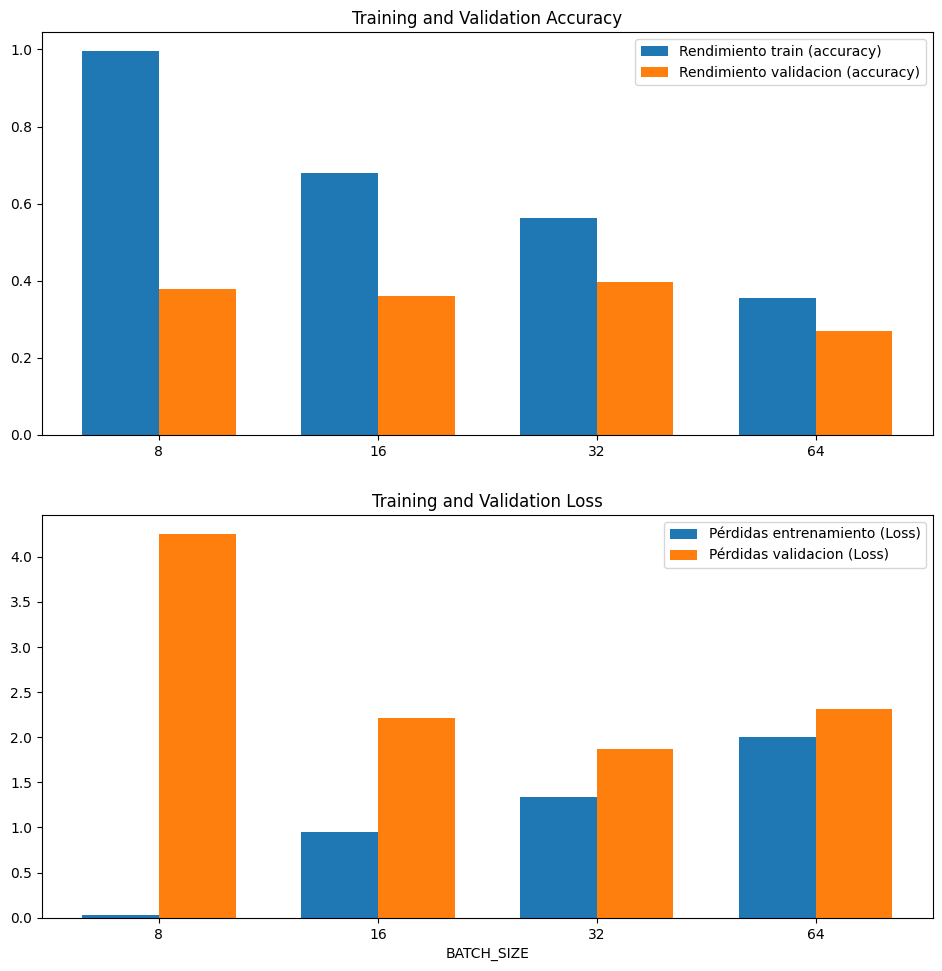

In [30]:
"""
history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []
"""

ind = np.arange(len(BATCH_SIZES))
width = 0.35

fig, axs = plt.subplots(2,1)
axs[0].bar(ind, train_acc_list,width,  label='Rendimiento train (accuracy)')
axs[0].bar(ind + width, test_acc_list,width,  label='Rendimiento validacion (accuracy)')
axs[0].legend(loc='upper right')
axs[0].set_title('Training and Validation Accuracy')

axs[0].set_xticks(ind + width / 2)
axs[0].set_xticklabels(BATCH_SIZES)




axs[1].bar(ind, train_loss_list,width,  label='Pérdidas entrenamiento (Loss)')
axs[1].bar(ind + width, test_loss_list,width,  label='Pérdidas validacion (Loss)')
axs[1].legend(loc='upper right')
axs[1].set_title('Training and Validation Loss')

axs[1].set_xticks(ind + width / 2)
axs[1].set_xticklabels(BATCH_SIZES)
axs[1].set_xlabel('BATCH_SIZE')


fig.set_size_inches(11.5, 11.5)
fig.set_dpi(100)
plt.show()

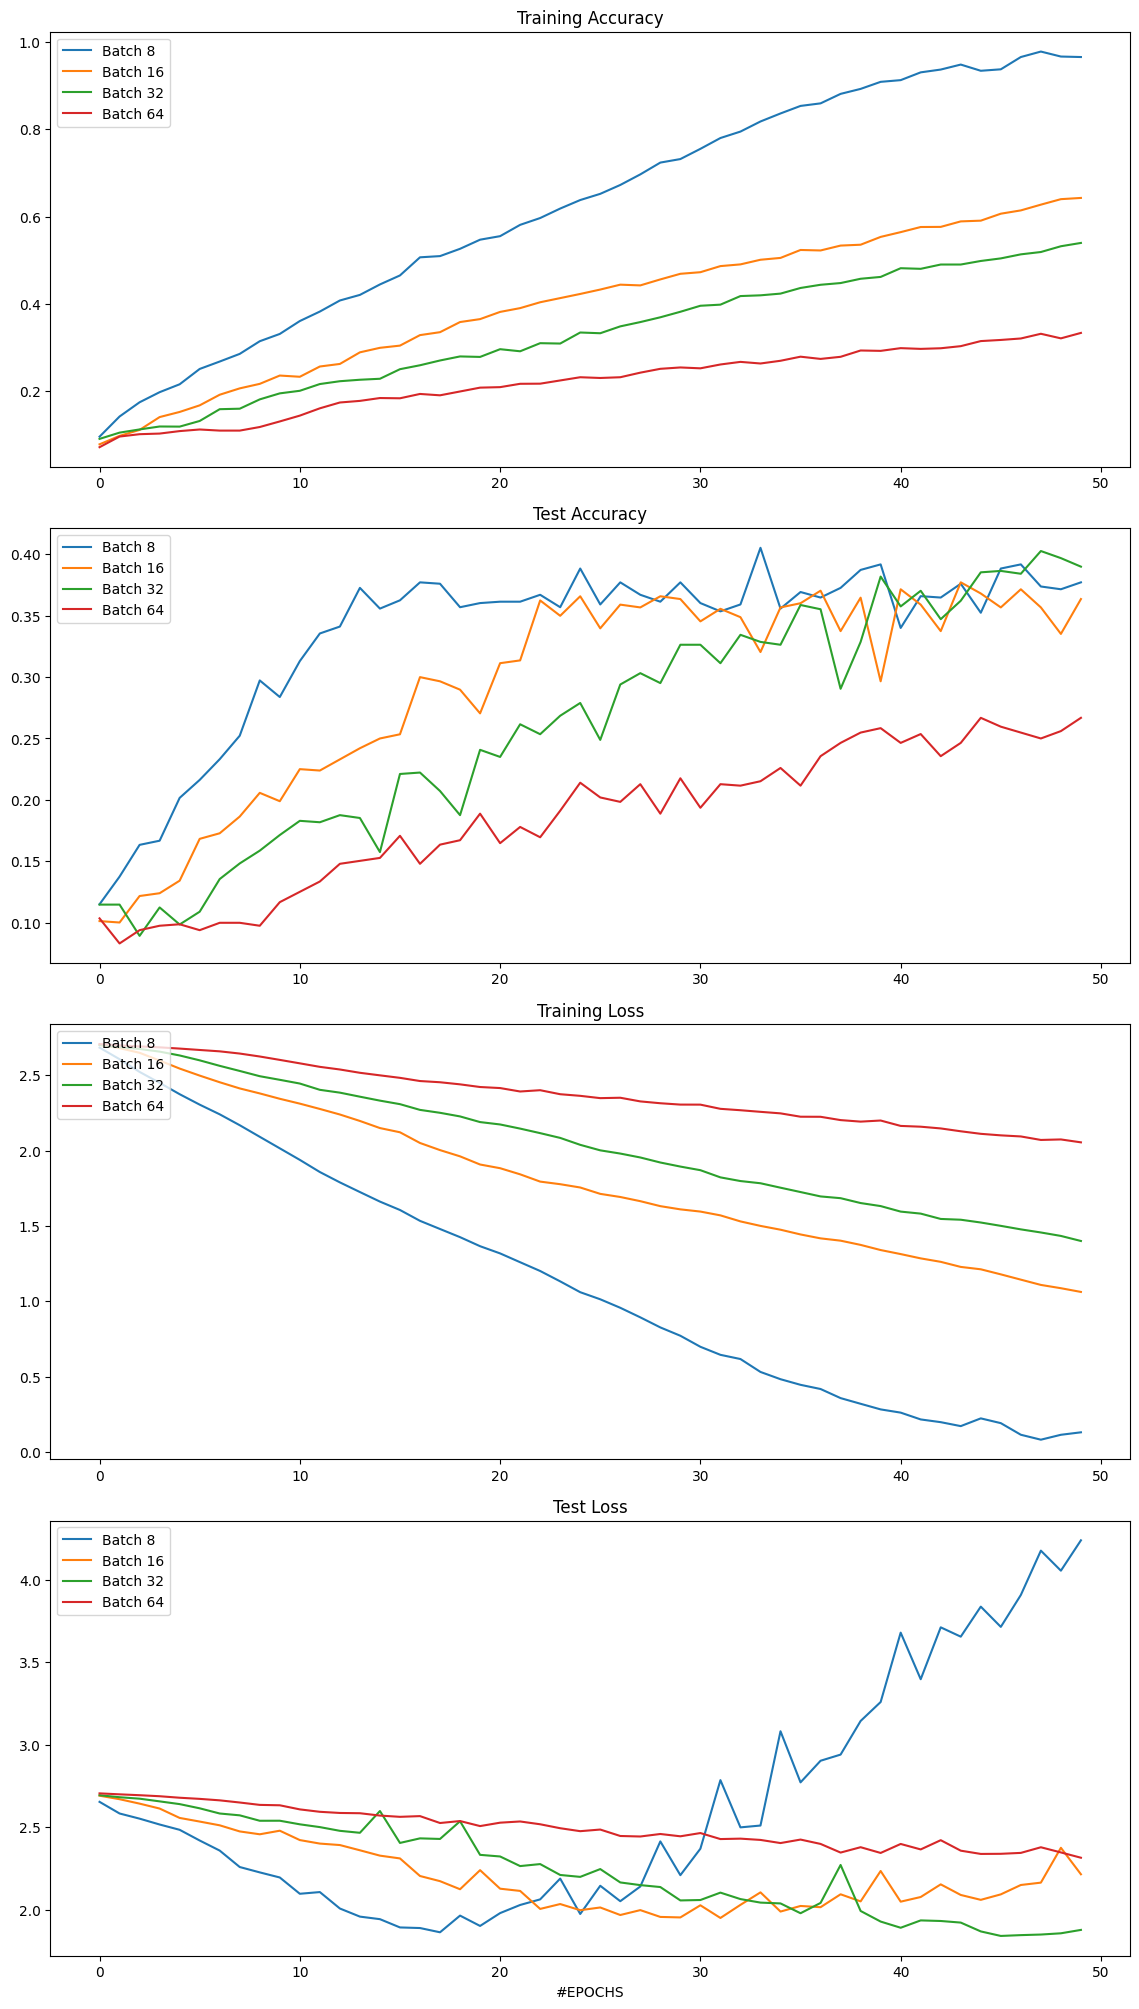

In [31]:
"""test_loss_list = []
test_acc_list = []

train_loss_list = []
train_acc_list = []

history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []
"""

fig, axs = plt.subplots(4,1)
epoch_list = np.arange(EPOCHS)

for idx, batch_size in enumerate(BATCH_SIZES):
  axs[0].plot(epoch_list, history_acc_list[idx],  label=f'Batch {batch_size}')
  axs[0].set_title(f'Training Accuracy')
  axs[0].legend(loc='upper left')

for idx, batch_size in enumerate(BATCH_SIZES):
  axs[1].plot(epoch_list, history_val_acc_list[idx],  label=f'Batch {batch_size}')
  axs[1].set_title(f'Test Accuracy')
  axs[1].legend(loc='upper left')


for idx, batch_size in enumerate(BATCH_SIZES):
  axs[2].plot(epoch_list, history_loss_list[idx],  label=f'Batch {batch_size}')
  axs[2].set_title(f'Training Loss')
  axs[2].legend(loc='upper left')


for idx, batch_size in enumerate(BATCH_SIZES):
  axs[3].plot(epoch_list, history_val_loss_list[idx],  label=f'Batch {batch_size}')
  axs[3].set_title(f'Test Loss')
  axs[3].legend(loc='upper left')





fig.set_size_inches(11.5, 20)
fig.set_dpi(100)
plt.tight_layout()
plt.xlabel("#EPOCHS")
plt.show()

In [ ]:
print("test_loss_list: ", test_loss_list)
print("test_acc_list: ", test_acc_list)

print("train_loss_list: ", train_loss_list)
print("train_acc_list: ", train_acc_list)

print("history_acc_list: ", history_acc_list)
print("history_val_acc_list: ", history_val_acc_list)
print("history_loss_list: ", history_loss_list)
print("history_val_loss_list: ", history_val_loss_list)

test_loss_list:  [4.011893272399902, 2.189121961593628, 2.171086549758911, 2.35896897315979]
test_acc_list:  [0.3986486494541168, 0.3920454680919647, 0.3055555522441864, 0.2475961595773697]
train_loss_list:  [0.07477614283561707, 0.7459102272987366, 1.614496111869812, 2.127495765686035]
train_acc_list:  [0.9830178022384644, 0.7645089030265808, 0.4693080484867096, 0.2974330484867096]
history_acc_list:  [[0.09688196331262589, 0.14114698767662048, 0.1820712685585022, 0.20879732072353363, 0.23691536486148834, 0.265868604183197, 0.3031737208366394, 0.33491089940071106, 0.3507795035839081, 0.35746103525161743, 0.3822382986545563, 0.39838528633117676, 0.41369709372520447, 0.4276169240474701, 0.4565701484680176, 0.4674276113510132, 0.4905345141887665, 0.5116926431655884, 0.5231069326400757, 0.542037844657898, 0.5634744167327881, 0.5826837420463562, 0.6046770811080933, 0.6197104454040527, 0.6277839541435242, 0.6545100212097168, 0.6773385405540466, 0.692650318145752, 0.7110245227813721, 0.736358